# 🧹 Préparation des données (Data Preparation)
Ce notebook contient l'analyse initiale et le formatage du dataset NSL-KDD :
- **Chargement** : Lecture de KDDTrain+.txt et KDDTest+.txt
- **Exploration** : Répartition des attaques et types de protocoles
- **Mapping** : Regroupement des 40 catégories en 5 classes principales (Normal, DoS, Probe, R2L, U2R)
- **Encodage** : One-Hot Encoding des variables catégorielles


## 1. Chargement des données
Importation de pandas et lecture du jeu de données brut depuis les fichiers texte.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.utils.class_weight import compute_class_weight



In [2]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

train_df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test_df = pd.read_csv('../data/KDDTest+.txt', names=columns)

train_df = train_df.drop('difficulty_level', axis=1)
test_df = test_df.drop('difficulty_level', axis=1)

print("Training Data Shape:", train_df.shape)
print(train_df.iloc[:,:5])

Training Data Shape: (125973, 42)
        duration protocol_type   service flag  src_bytes
0              0           tcp  ftp_data   SF        491
1              0           udp     other   SF        146
2              0           tcp   private   S0          0
3              0           tcp      http   SF        232
4              0           tcp      http   SF        199
...          ...           ...       ...  ...        ...
125968         0           tcp   private   S0          0
125969         8           udp   private   SF        105
125970         0           tcp      smtp   SF       2231
125971         0           tcp    klogin   S0          0
125972         0           tcp  ftp_data   SF        151

[125973 rows x 5 columns]


## 2. Exploration initiale
Aperçu de la distribution des étiquettes et analyse exploratoire des attaques de base.

In [3]:
train_df.label.value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

## 3. Mapping des labels d'attaque
Création d'un dictionnaire pour regrouper les 40 catégories spécifiques en 5 grandes familles d'attaques.

In [4]:
attack_mapping = {
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS', 'land': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',
    'warezclient': 'R2L', 'guess_passwd': 'R2L', 'warezmaster': 'R2L', 'imap': 'R2L', 
    'ftp_write': 'R2L', 'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'buffer_overflow': 'U2R', 'rootkit': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'normal': 'Normal'
}

train_df['attack_class'] = train_df['label'].map(attack_mapping)
test_df['attack_class'] = test_df['label'].map(attack_mapping)
train_df = train_df.drop('label', axis=1)
test_df = test_df.drop('label', axis=1)
train_df.attack_class.value_counts()

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [5]:
train_df.select_dtypes(include=['object'])

C:\Users\youss\AppData\Local\Temp\ipykernel_17548\2476900635.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.select_dtypes(include=['object'])


,protocol_type,service,flag,attack_class
0,tcp,ftp_data,SF,Normal
1,udp,other,SF,Normal
2,tcp,private,S0,DoS
3,tcp,http,SF,Normal
4,tcp,http,SF,Normal
...,...,...,...,...
125968,tcp,private,S0,DoS
125969,udp,private,SF,Normal
125970,tcp,smtp,SF,Normal
125971,tcp,klogin,S0,DoS


In [6]:
print("Unique Protocol Types:", train_df['protocol_type'].unique())
print("Unique Services:", train_df['service'].unique())
print("Unique Flags:", train_df['flag'].unique())
print("Unique Attack Classes:", train_df['attack_class'].unique())

Unique Protocol Types: <ArrowStringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str
Unique Services: <ArrowStringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'print

## 4. Encodage des variables catégorielles (One-Hot Encoding)
Conversion des variables de type texte (protocole, service, flag) en variables numériques.

In [7]:
class_mapping = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}
train_df['attack_class'] = train_df['attack_class'].map(class_mapping)
test_df['attack_class'] = test_df['attack_class'].map(class_mapping)

X_train_raw = train_df.drop(['attack_class'], axis=1)
X_test_raw = test_df.drop(['attack_class'], axis=1)

categorical_cols = ['protocol_type', 'service', 'flag']
X_train = pd.get_dummies(X_train_raw, columns=categorical_cols)
X_test = pd.get_dummies(X_test_raw, columns=categorical_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

train_df= train_df.drop(columns=categorical_cols)
test_df= test_df.drop(columns=categorical_cols)


Training features shape: (125973, 122)
Testing features shape: (22544, 122)


In [8]:
train_df.select_dtypes(include=['object'])

""
0
1
2
3
4
...
125968
125969
125970
125971


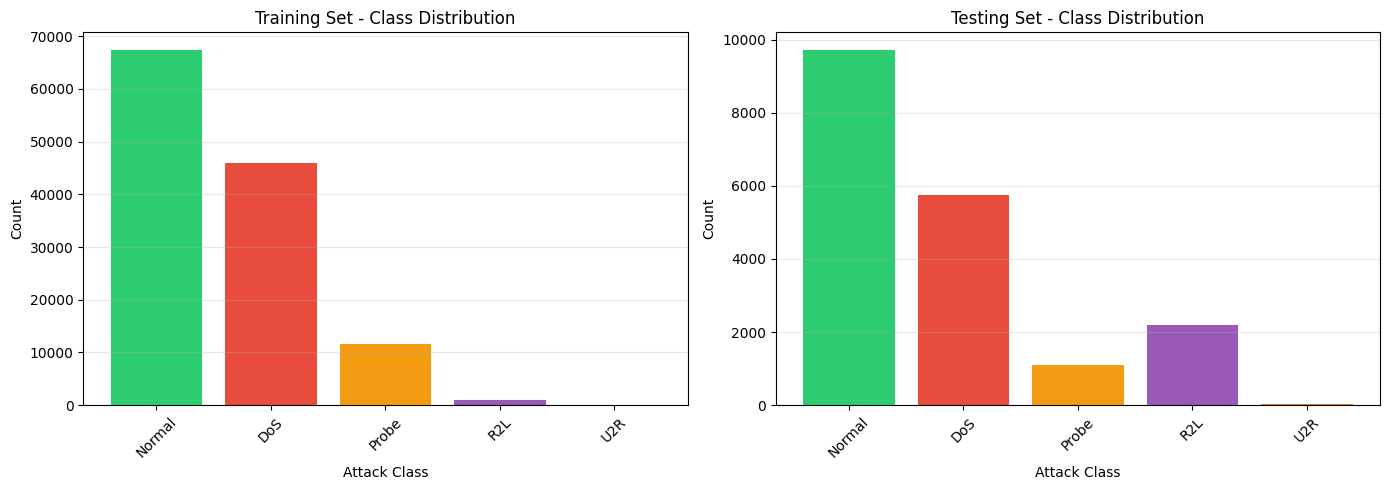

In [9]:
y_train = train_df['attack_class']
y_test = test_df['attack_class']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
y_train_counts = y_train.value_counts().sort_index()
axes[0].bar(y_train_counts.index, y_train_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22'])
axes[0].set_xlabel('Attack Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([class_names[i] for i in range(5)], rotation=45)
axes[0].grid(axis='y', alpha=0.3)

y_test_counts = y_test.value_counts().sort_index()
axes[1].bar(y_test_counts.index, y_test_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22'])
axes[1].set_xlabel('Attack Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Testing Set - Class Distribution')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([class_names[i] for i in range(5)], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Normalisation (StandardScaler)
Mise à l'échelle des données pour équilibrer l'impact de chaque caractéristique numérique.

In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Mean: {X_train_scaled.mean().mean():.6f} ")
print(f"Std:  {X_train_scaled.std().mean():.6f} ")

Mean: 0.000000 
Std:  0.991807 


## 6. Gestion du déséquilibre (class weights)
Calcul des poids pour compenser la sous-représentation critique de certaines classes comme U2R.

Normal     - Weight: 0.3741  (Samples: 67,343)
DoS        - Weight: 0.5486  (Samples: 45,927)
Probe      - Weight: 2.1615  (Samples: 11,656)
R2L        - Weight: 25.3212  (Samples: 995)
U2R        - Weight: 484.5115  (Samples: 52)


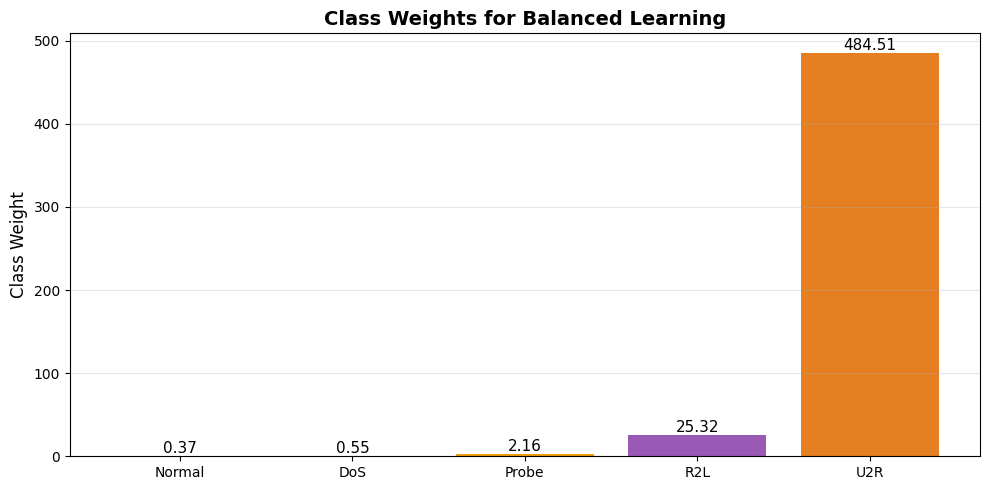

In [11]:

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))

class_names = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
for class_idx, weight in class_weights_dict.items():
    count = y_train.value_counts()[class_idx]
    print(f"{class_names[class_idx]:<10} - Weight: {weight:.4f}  (Samples: {count:,})")


fig, ax = plt.subplots(figsize=(10, 5))
weights = [class_weights_dict[i] for i in range(5)]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22']
bars = ax.bar([class_names[i] for i in range(5)], weights, color=colors)
ax.set_ylabel('Class Weight', fontsize=12)
ax.set_title('Class Weights for Balanced Learning', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, weight in zip(bars, weights):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

